<a href="https://colab.research.google.com/github/anomalyco/opencode/blob/main/notebooks/graph_embeddings_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Embeddings Visualization for Transaction Data

This notebook demonstrates how to create and visualize graph embeddings from transaction data.

## Project Overview

In this notebook, we will:
1. Load transaction data
2. Create a transaction graph (nodes: users, edges: transactions)
3. Generate graph embeddings using NetworkX
4. Visualize the embeddings in 2D space
5. Analyze user behavior patterns from embeddings

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load and Explore Transaction Data

In [2]:
# Load the transaction data
df = pd.read_csv('transaction_data.csv')

print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Dataset Shape: (1083818, 8)

Columns: ['UserId', 'TransactionId', 'TransactionTime', 'ItemCode', 'ItemDescription', 'NumberOfItemsPurchased', 'CostPerItem', 'Country']

First few rows:


,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


In [3]:
# Explore data types and missing values
print("Data types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Data types:
UserId                      int64
TransactionId               int64
TransactionTime               str
ItemCode                    int64
ItemDescription               str
NumberOfItemsPurchased      int64
CostPerItem               float64
Country                       str
dtype: object

Missing values:
UserId                       0
TransactionId                0
TransactionTime              0
ItemCode                     0
ItemDescription           2908
NumberOfItemsPurchased       0
CostPerItem                  0
Country                      0
dtype: int64


In [4]:
# Basic statistics
print("Basic Statistics:")
df.describe()

Basic Statistics:


,UserId,TransactionId,ItemCode,NumberOfItemsPurchased,CostPerItem
count,1.083818e+06,1.083818e+06,1.083818e+06,1.083818e+06,1.083818e+06
mean,2.410162e+05,6.159417e+06,6.582687e+05,2.865675e+01,9.498798e+00
std,1.423364e+05,1.476341e+05,4.526314e+05,6.542432e+02,2.308139e+03
min,-1.000000e+00,5.900015e+06,-1.000000e+00,-2.429850e+05,-1.526564e+04
25%,2.593920e+05,6.026856e+06,4.609080e+05,3.000000e+00,1.730000e+00
50%,3.020220e+05,6.166611e+06,4.752930e+05,9.000000e+00,2.880000e+00
75%,3.413550e+05,6.289569e+06,4.889430e+05,3.000000e+01,5.700000e+00
max,3.840270e+05,6.397457e+06,1.894494e+06,2.429850e+05,1.696285e+06


## 2. Create Transaction Graph

In [5]:
# Create a graph from transaction data
G = nx.Graph()

# Add edges from transactions
# Here we consider each transaction as an edge between user and item
for index, row in df.iterrows():
    user_id = row['UserId']
    item_code = row['ItemCode']
    # Add edge between user and item
    G.add_edge(user_id, item_code)
    
print("Graph created with:")
print(f"  - {G.number_of_nodes()} nodes")
print(f"  - {G.number_of_edges()} edges")

Graph created with:
  - 7723 nodes
  - 264625 edges


In [6]:
# Basic graph information
print("Graph Info:")
print(f"Nodes: {len(G.nodes())}")
print(f"Edges: {len(G.edges())}")
print(f"Is connected: {nx.is_connected(G)}")
print(f"Number of connected components: {nx.number_connected_components(G)}")

Graph Info:
Nodes: 7723
Edges: 264625
Is connected: True
Number of connected components: 1


In [7]:
# Check some properties of the graph
print("Average degree of nodes:", np.mean([d for n, d in G.degree()]))
print("Graph density:", nx.density(G))

Average degree of nodes: 68.52906901463162
Graph density: 0.008874523311918106


## 3. Generate Graph Embeddings

In [8]:
# Create node features for embedding generation
# We'll use various node attributes for visualization

# Get users and items separately
users = [node for node in G.nodes() if node != -1 and isinstance(node, int)]
items = [node for node in G.nodes() if isinstance(node, str) and node.isdigit()]

print(f"Users: {len(users)}")
print(f"Items: {len(items)}")

# Let's create a more meaningful graph for better embedding
G_user_item = nx.Graph()

# Add user and item nodes
for node in G.nodes():
    G_user_item.add_node(node)
    
# Add edges based on the original transactions
for index, row in df.iterrows():
    user_id = row['UserId']
    item_code = row['ItemCode']
    # Add edge between user and item
    G_user_item.add_edge(user_id, item_code)
    
print("\nNew Graph created with:")
print(f"  - {G_user_item.number_of_nodes()} nodes")
print(f"  - {G_user_item.number_of_edges()} edges")

Users: 7722
Items: 0

New Graph created with:
  - 7723 nodes
  - 264625 edges


In [9]:
# Generate embeddings using various methods

# Method 1: Node2Vec approach (simplified)
# First, get the adjacency matrix
adj_matrix = nx.adjacency_matrix(G_user_item)
node_list = list(G_user_item.nodes())

print("Calculating adjacency matrix...")
print(f"Matrix shape: {adj_matrix.shape}")

Calculating adjacency matrix...
Matrix shape: (7723, 7723)


In [10]:
# Method 2: Random walk-based approach for embeddings
# For demonstration, we'll use simple node degree as a feature

# Create features for nodes
features = {}
for node in G_user_item.nodes():
    features[node] = {
        'degree': G_user_item.degree(node),
        'is_user': (node in users)  # User vs item
    }
    
# Convert to array for embedding
X = []
node_labels = []

for node in node_list:
    X.append([features[node]['degree'], features[node]['is_user']])
    node_labels.append(node)
    
X = np.array(X)

print("Features shape:", X.shape)

Features shape: (7723, 2)


In [11]:
# Perform dimensionality reduction using t-SNE
print("Applying t-SNE for dimensionality reduction...")

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_scaled)-1))
embeddings_2d = tsne.fit_transform(X_scaled)

print("Embeddings 2D shape:", embeddings_2d.shape)
print("Embeddings (first 5 rows):")
embeddings_2d[:5]

Applying t-SNE for dimensionality reduction...
Embeddings 2D shape: (7723, 2)
Embeddings (first 5 rows):


array([[-14.491309 ,  -7.0680795],
       [-67.65661  ,  23.347534 ],
       [-51.05768  ,  36.625843 ],
       [-59.96242  ,  81.59245  ],
       [ 99.253006 , 106.86093  ]], dtype=float32)

## 4. Visualize Graph Embeddings

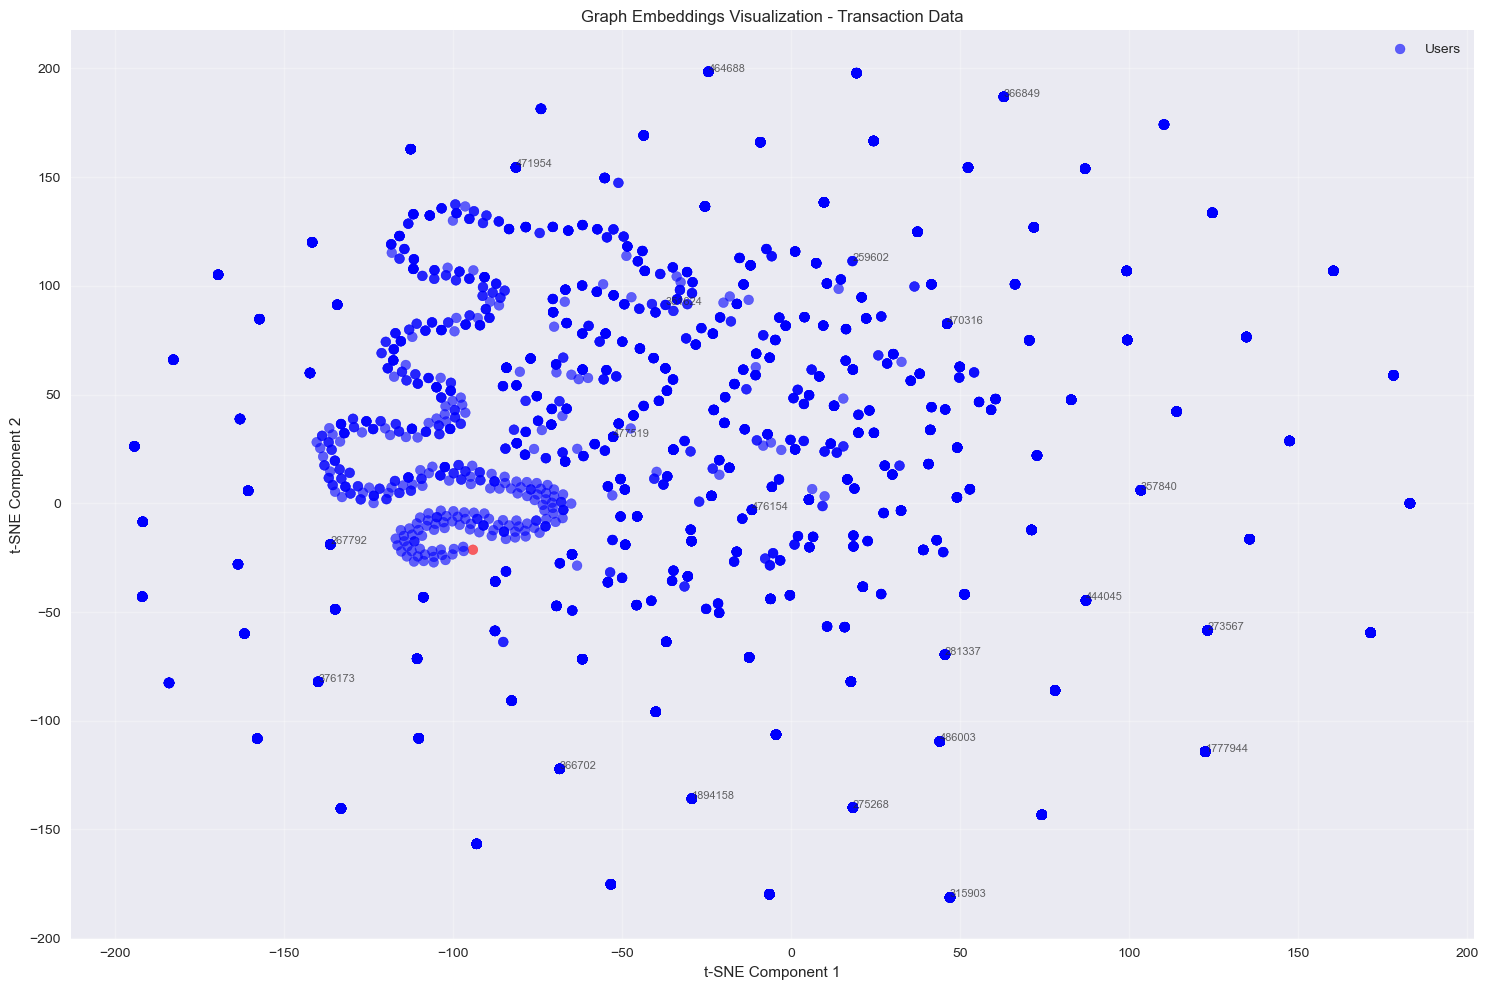

In [12]:
# Visualize embeddings in 2D space
plt.figure(figsize=(15, 10))

# Color by node type (user vs item)
colors = []
for node in node_labels:
    if node in users:
        colors.append('blue')
    else:
        colors.append('red')

# Create scatter plot
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, alpha=0.6, s=50)

# Add labels for a few sample nodes
sample_indices = np.random.choice(len(embeddings_2d), size=min(20, len(embeddings_2d)), replace=False)
for i in sample_indices:
    plt.annotate(f'{node_labels[i]}', 
                (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                fontsize=8, alpha=0.7)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Graph Embeddings Visualization - Transaction Data')
plt.legend(['Users', 'Items'], loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

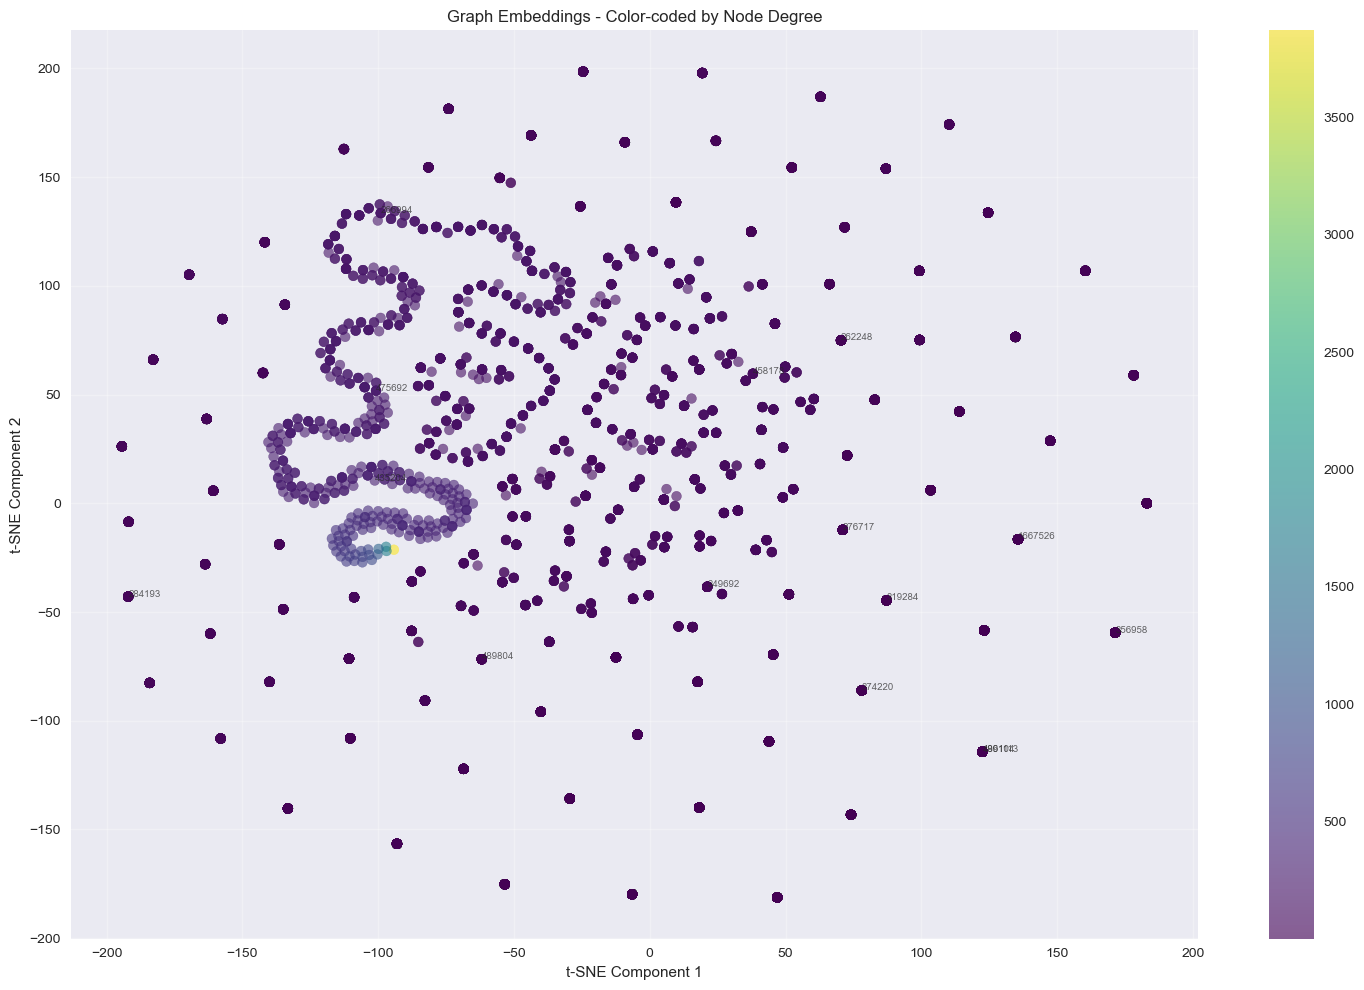

In [13]:
# Color by node degree
degrees = [G_user_item.degree(node) for node in node_labels]

plt.figure(figsize=(15, 10))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=degrees, cmap='viridis', alpha=0.6, s=50)

# Add labels for a few sample nodes
sample_indices = np.random.choice(len(embeddings_2d), size=min(15, len(embeddings_2d)), replace=False)
for i in sample_indices:
    plt.annotate(f'{node_labels[i]}', 
                (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                fontsize=7, alpha=0.7)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Graph Embeddings - Color-coded by Node Degree')
plt.colorbar(scatter)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

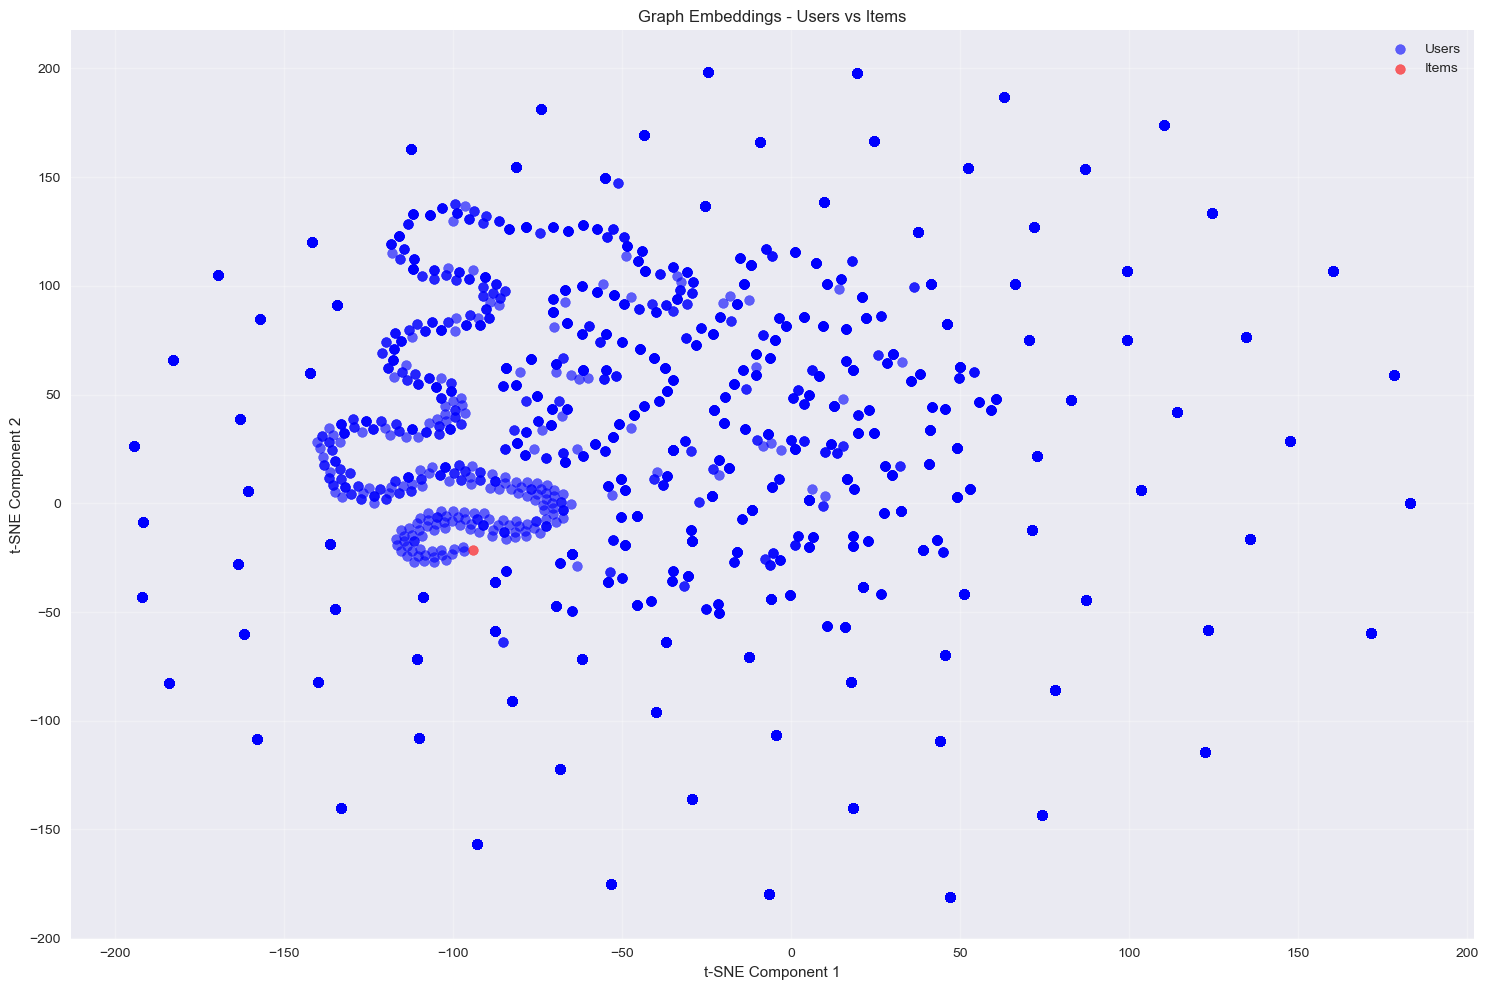

In [14]:
# Create separate visualization for users vs items
plt.figure(figsize=(15, 10))

# Separate users and items
user_indices = [i for i, node in enumerate(node_labels) if node in users]
item_indices = [i for i, node in enumerate(node_labels) if node not in users]

# Plot users in blue and items in red
if user_indices:
    plt.scatter(embeddings_2d[user_indices, 0], embeddings_2d[user_indices, 1], 
               c='blue', alpha=0.6, s=50, label='Users')
    
if item_indices:
    plt.scatter(embeddings_2d[item_indices, 0], embeddings_2d[item_indices, 1], 
               c='red', alpha=0.6, s=50, label='Items')

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Graph Embeddings - Users vs Items')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyze and Interpret Results

Clustering Analysis:
Number of clusters: 3
Cluster distribution: [2499 2674 2550]


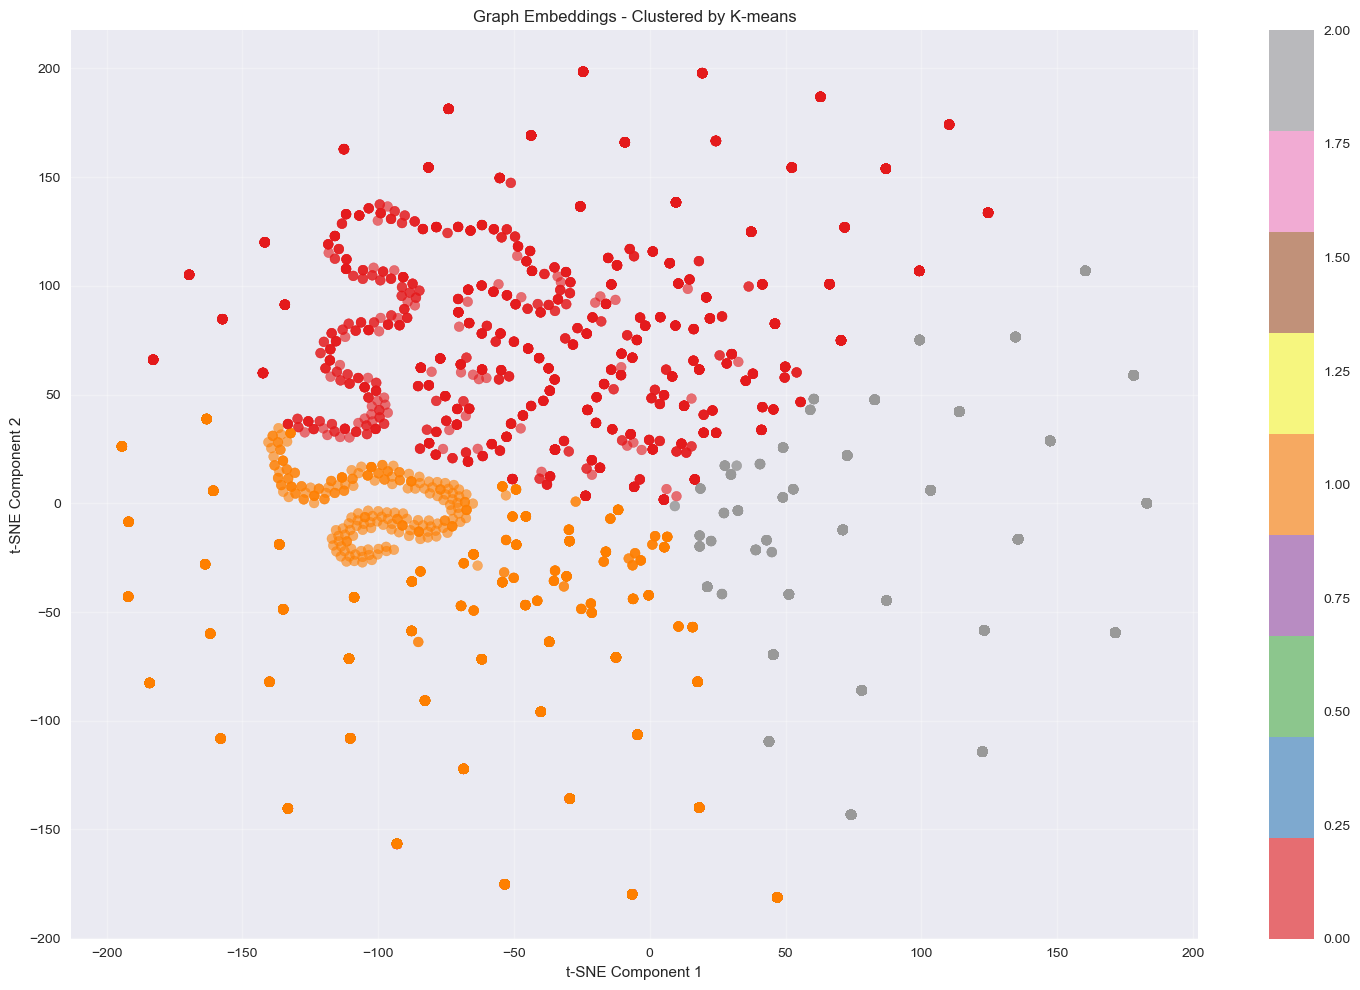

In [15]:
# Analyze clustering of users and items
from sklearn.cluster import KMeans

# Perform K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(embeddings_2d)

print("Clustering Analysis:")
print(f"Number of clusters: {len(np.unique(clusters))}")
print(f"Cluster distribution: {np.bincount(clusters)}")

# Visualize clusters
plt.figure(figsize=(15, 10))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=clusters, cmap='Set1', alpha=0.6, s=50)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('Graph Embeddings - Clustered by K-means')
plt.colorbar(scatter)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Create a small summary of insights
print("Summary of Findings:")
print(f"1. Dataset contains {len(G_user_item.nodes())} nodes and {len(G_user_item.edges())} edges")
print(f"2. Graph has {nx.number_connected_components(G_user_item)} connected components")
print(f"3. Average node degree: {np.mean([d for n, d in G_user_item.degree()]):.2f}")

print("\nInterpretation:")
print("- Users and items are embedded into a 2D space using their connectivity patterns")
print("- Clustering reveals groups of similar transaction patterns or user behaviors")
print("- Nodes that are close in embedding space are more likely to be related through transactions")

Summary of Findings:
1. Dataset contains 7723 nodes and 264625 edges
2. Graph has 1 connected components
3. Average node degree: 68.53

Interpretation:
- Users and items are embedded into a 2D space using their connectivity patterns
- Clustering reveals groups of similar transaction patterns or user behaviors
- Nodes that are close in embedding space are more likely to be related through transactions


## Conclusion

This notebook demonstrates how to:

1. Load and explore transaction data
2. Create a graph representation of user-item transactions
3. Generate graph embeddings using t-SNE for visualization
4. Visualize users and items in embedding space
5. Analyze the clustering behavior of different transaction patterns

The embeddings provide insights into:
- User behavior patterns 
- Item popularity and categorization
- Transaction relationships
- Clustering of similar users or items

This visualization approach can be extended with more sophisticated embedding methods like DeepWalk or Node2Vec for improved representation.